# Oligodendrocyte Gene Programs in the Aging Human Brain

This tutorial walks through the full **stGP** pipeline on the human brain MERFISH dataset
(Jeffries et al., *Nature* 2025), using **Oligodendrocytes (oli)** as the target cell type.

## 1. Setup

In [1]:
%matplotlib inline

import os, sys, warnings, pickle
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import scipy.sparse as sp
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)
sys.path.insert(0, "..")

DATA_QC      = Path("data/qc/human_merfish_qc.h5ad")
DATA_PROC    = Path("data/processed")
RESULTS_DIR  = Path("Results/stgp")
FIGURES_DIR  = Path("Figure/oli")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CELLTYPE = "oli"   # target cell type for this tutorial
adata_oli = sc.read_h5ad(DATA_PROC / f"{CELLTYPE}.h5ad")

---
## 2. Fitting stGP

stGP models gene expression in each tissue slice as a sum of **p latent programs**.
Each program is characterised by:
- **W** (gene loadings, `p × G`): non-negative gene weights defining the program
- **H** (cell scores, `N × p`): overall activity of each program in each cell
- **b** (spatial field, `N × p`): spatially smooth residual component
- **α** (age effect, `p × S`): how program amplitude varies across slices/ages
- **$\sigma_{age}^2$, $\tau_{spa}^2$** (variance components, `p × 2`): strength of temporal and spatial effects of each program

The model rank **p** is selected automatically by greedy forward selection.

In [2]:
import time
from stgp.estimation import fit_pfactor_auto
from stgp.kernels import (
    bandwidth_select_spatial, bandwidth_select_temporal,
    build_K_age, build_K_spa_list_from_stacked
)
from stgp.preprocessing import standardize_coords_list

OUT_DIR = RESULTS_DIR / CELLTYPE
OUT_DIR.mkdir(parents=True, exist_ok=True)
PKL_PATH = OUT_DIR / "stgp_result.pkl"


def balanced_normalize(Y_list, target_sum=None, eps=1e-12, max_scale=10.0):
    Y_list = [np.asarray(Y, dtype=float) for Y in Y_list]
    all_lib = np.concatenate([Y.sum(axis=1) for Y in Y_list])
    if target_sum is None:
        target_sum = np.median(all_lib[all_lib > 0])

    X_list = []
    for Y in Y_list:
        lib = Y.sum(axis=1, keepdims=True)
        scale = target_sum / np.maximum(lib, eps)
        if max_scale is not None:
            scale = np.minimum(scale, max_scale)
        X_list.append(np.log1p(Y * scale))

    gene_mean = np.mean([X.mean(axis=0) for X in X_list], axis=0)
    X_list = [X - gene_mean for X in X_list]
    return X_list, gene_mean, target_sum


age_arr = pd.to_numeric(adata_oli.obs["age"], errors="coerce").to_numpy(float)
groups = adata_oli.obs["id_region"].astype(str).to_numpy()
uniq, inv = np.unique(groups, return_inverse=True)
idx_per_group = [np.sort(np.where(inv == t)[0]) for t in range(len(uniq))]

X_raw = adata_oli.X.toarray() if sp.issparse(adata_oli.X) else np.asarray(adata_oli.X)
Y_raw_list = [X_raw[ix, :] for ix in idx_per_group]
Y_list, _, _ = balanced_normalize(Y_raw_list)
nlist = np.array([len(ix) for ix in idx_per_group])
ages = np.array([age_arr[ix[0]] for ix in idx_per_group])
slices = uniq.copy()  # Match 02_run_stgp.py: keep np.unique(id_region) order.


In [3]:
# ── Build GP kernels ─────────────────────────────────────────────────────
coords_list = standardize_coords_list([adata_oli.obsm["spatial"][ix] for ix in idx_per_group])
gamma_spa = bandwidth_select_spatial(coords_list, frac=0.01, rho=0.75)
gamma_age = bandwidth_select_temporal(ages, rho=np.exp(-2))
print(f"  gamma_spa = {gamma_spa:.4f}  |  gamma_age = {gamma_age:.4f}")

K_age = build_K_age(ages, gamma_age, kernel="rbf", standardize=True)
K_spa_list = build_K_spa_list_from_stacked(
    np.vstack(coords_list), nlist, gamma_spa, standardize=False, jitter=1e-6
)


  gamma_spa = 0.1402  |  gamma_age = 0.8247


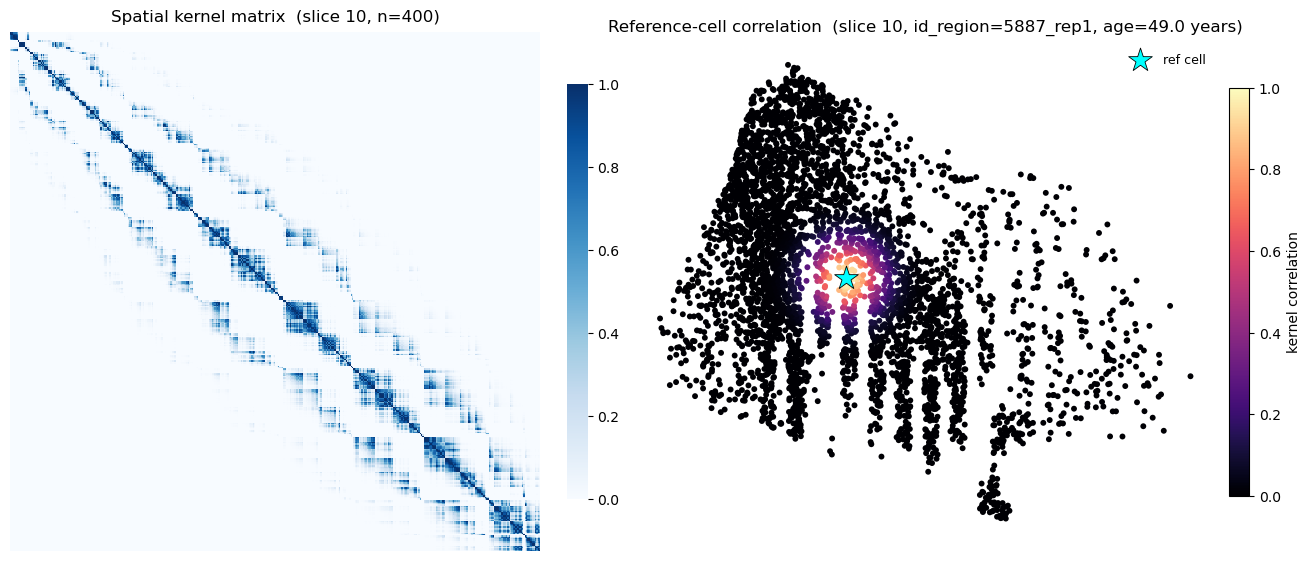

In [4]:
from plots import plot_spatial_kernel_corr_combined
fig = plot_spatial_kernel_corr_combined(
    adata=adata_oli, bandwidth=float(gamma_spa),
    slice_idx=10,
    age_unit="years",
)

In [5]:
t0 = time.perf_counter()
res = fit_pfactor_auto(
    Y_list=Y_list,
    Nlist=nlist,
    K_age=K_age,
    Kspa_list=K_spa_list,
    p_max=10,
    k=15,
    inner_rank1_tol=1e-4,
    rel_improve_total_tol=0.01,
    backfit_tol=1e-4,
    random_state=0,
    verbose=1,
)
print(f"Runtime: {time.perf_counter() - t0:.1f}s  |  programs selected: {res['W'].shape[0]}")

# ── Save results ─────────────────────────────────────────────────────────
res["gamma_age"] = gamma_age
res["gamma_spa"] = gamma_spa
with open(PKL_PATH, "wb") as f:
    pickle.dump(res, f)
print(f"Saved: {PKL_PATH}")


[sweep=001] dW_rel=2.075e-01 dTheta_rel=2.777e-02 time=9.717e+00
[sweep=002] dW_rel=1.278e-01 dTheta_rel=3.274e-02 time=9.971e+00
[sweep=003] dW_rel=4.878e-02 dTheta_rel=1.027e-02 time=7.161e+00
[sweep=004] dW_rel=2.982e-02 dTheta_rel=3.650e-03 time=5.240e+00
[sweep=005] dW_rel=2.186e-02 dTheta_rel=2.593e-03 time=3.957e+00
[sweep=006] dW_rel=1.683e-02 dTheta_rel=2.074e-03 time=3.700e+00
[sweep=007] dW_rel=1.340e-02 dTheta_rel=1.709e-03 time=3.398e+00
[sweep=008] dW_rel=1.092e-02 dTheta_rel=1.420e-03 time=3.347e+00
[sweep=009] dW_rel=9.047e-03 dTheta_rel=1.143e-03 time=2.853e+00
[sweep=010] dW_rel=7.609e-03 dTheta_rel=9.437e-04 time=3.097e+00
[sweep=011] dW_rel=6.511e-03 dTheta_rel=8.821e-04 time=2.730e+00
[sweep=012] dW_rel=5.573e-03 dTheta_rel=7.274e-04 time=2.569e+00
[sweep=013] dW_rel=4.836e-03 dTheta_rel=5.926e-04 time=2.297e+00
[sweep=014] dW_rel=4.224e-03 dTheta_rel=5.520e-04 time=2.531e+00
[sweep=015] dW_rel=3.674e-03 dTheta_rel=4.442e-04 time=2.250e+00
[sweep=016] dW_rel=3.259e

In [6]:
# ── Attach scores to AnnData & save ─────────────────────────────────────────
ADATA_PATH = OUT_DIR / "adata_with_scores.h5ad"

adata = adata_oli.copy()
all_idx = np.concatenate(idx_per_group)  # res["H"] rows follow np.unique(id_region) group order.
H_arr = np.empty_like(res["H"])
H_arr[all_idx] = res["H"]
b_arr = np.empty_like(res["b"])
b_arr[all_idx] = res["b"]
adata.obsm["X_stgp"] = H_arr.astype(np.float32)
adata.obsm["X_stgp_spatial"] = b_arr.astype(np.float32)

alpha_arr = np.asarray(res.get("alpha", []))
alpha_lower_arr = np.asarray(res.get("alpha_lower", []))
alpha_upper_arr = np.asarray(res.get("alpha_upper", []))
theta_arr = np.asarray(res.get("theta", []))
p_sel = res["W"].shape[0]
adata.uns["stgp"] = dict(
    groups=uniq.tolist(),
    ages=ages.tolist(),
    gamma_age=float(res["gamma_age"]),
    gamma_spa=float(res["gamma_spa"]),
    p_selected=p_sel,
    alpha=alpha_arr.tolist() if alpha_arr.ndim == 2 else [],
    alpha_lower=alpha_lower_arr.tolist() if alpha_lower_arr.ndim == 2 else [],
    alpha_upper=alpha_upper_arr.tolist() if alpha_upper_arr.ndim == 2 else [],
    theta=theta_arr.tolist() if theta_arr.ndim == 2 else [],
    sigma2e=float(res.get("sigma2e", np.nan)),
)
adata.write_h5ad(str(ADATA_PATH), compression="gzip")

# Also write W.csv and a long-form active-gene table for enrichment/downstream plots.
prog_labels = [f"stGP{j + 1}" for j in range(p_sel)]
W_df = pd.DataFrame(res["W"], index=prog_labels, columns=adata.var_names.astype(str))
W_df.to_csv(OUT_DIR / "W.csv")
W_long = (
    W_df.stack()
    .rename_axis(["program", "gene"])
    .rename("weight")
    .reset_index()
)
W_long = W_long[W_long["weight"] > 0].copy()
W_long = W_long.sort_values(["program", "weight"], ascending=[True, False])
W_long["rank"] = W_long.groupby("program").cumcount() + 1
W_long.to_csv(OUT_DIR / "W_active_genes.csv", index=False)


In [7]:
W_df = pd.read_csv(OUT_DIR / "W.csv", index_col=0)
W_df.index = [f"stGP{i+1}" for i in range(len(W_df))]

print("Top 10 genes per program:")
for prog, row in W_df.iterrows():
    top = row[row > 0].sort_values(ascending=False).head(10)
    print(f"  {prog}: {', '.join(top.index.tolist())}")

Top 10 genes per program:
  stGP1: SLC17A7, SLC1A2, MEIS3, C1QL3, APBA2, SATB2, ID2, SYT5, ACTL6B, RNF208
  stGP2: GAD1, OLIG1, AQP4, RBPJ, SLC1A2, TOP2B, MED13, SDHA, MAT2A, EXOSC6
  stGP3: GAD1, RPL3, RPL8, RPL7A, SOX2, FKBP5, FSD1, RPL10A, PHB2, MRPS26
  stGP4: SORCS2, RGS11, MOG, FKBP5, MAT2A, PDIA2, OLIG1, IWS1, SOX2, OLIG2


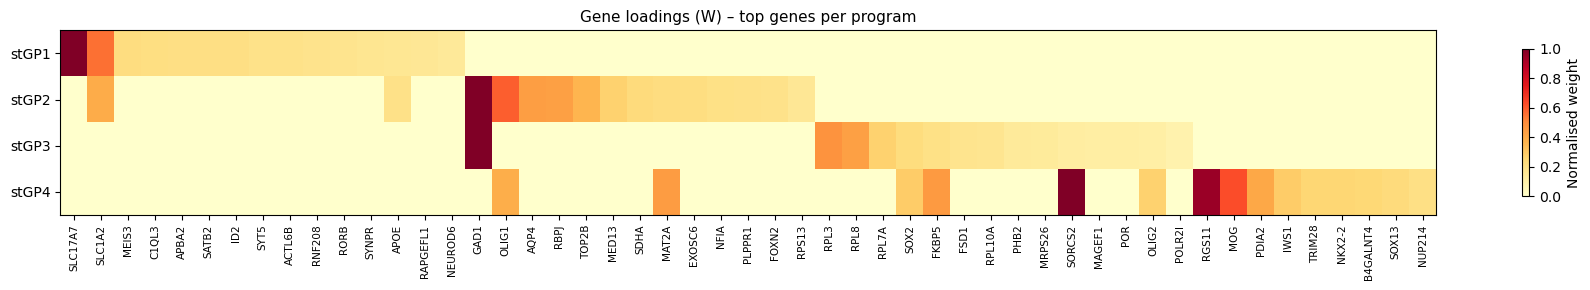

In [10]:
# ── Heatmap: top genes across all programs ───────────────────────────────────
n_top = 15
top_genes_per_prog = []
for _, row in W_df.iterrows():
    top_genes_per_prog.extend(row[row > 0].sort_values(ascending=False).head(n_top).index.tolist())
top_genes = list(dict.fromkeys(top_genes_per_prog))  # preserve order, deduplicate

W_sub = W_df[top_genes]
# Normalise each row to [0, 1] for visualisation
W_norm = W_sub.div(W_sub.max(axis=1) + 1e-12, axis=0)

fig, ax = plt.subplots(figsize=(min(0.4 * len(top_genes) + 2, 18), 3))
im = ax.imshow(W_norm.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
ax.set_yticks(range(len(W_df))); ax.set_yticklabels(W_df.index)
ax.set_xticks(range(len(top_genes)))
ax.set_xticklabels(top_genes, rotation=90, fontsize=7.5)
ax.set_title("Gene loadings (W) – top genes per program", fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.8, label="Normalised weight")
plt.tight_layout()
#plt.savefig(FIGURES_DIR / "W_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

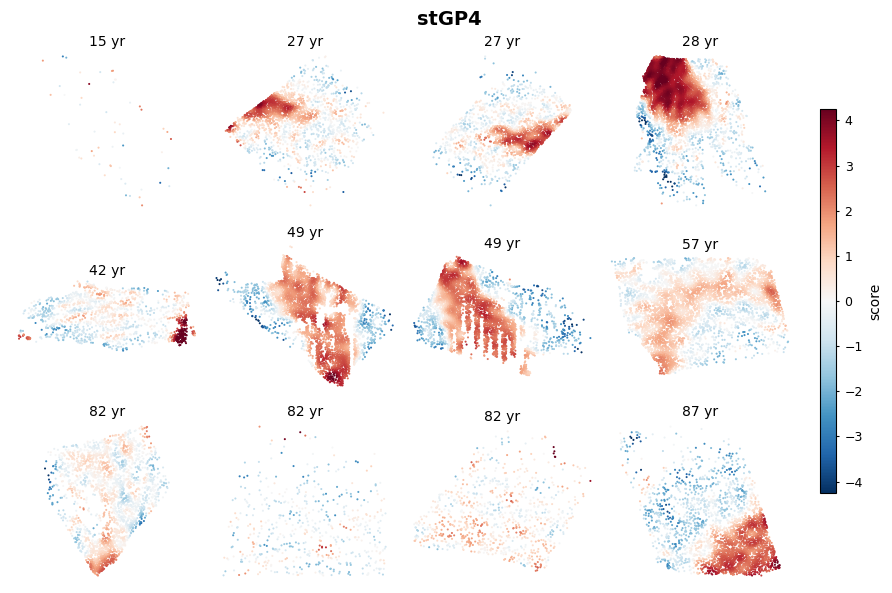

In [ ]:
from IPython.display import display

from plots import plot_spatial_program_all_slices
plot_spatial_program_all_slices(
    adata,
    "stGP4",
    out_dir=FIGURES_DIR,
    stem="spatial_stGP4",
    title="stGP4",
);

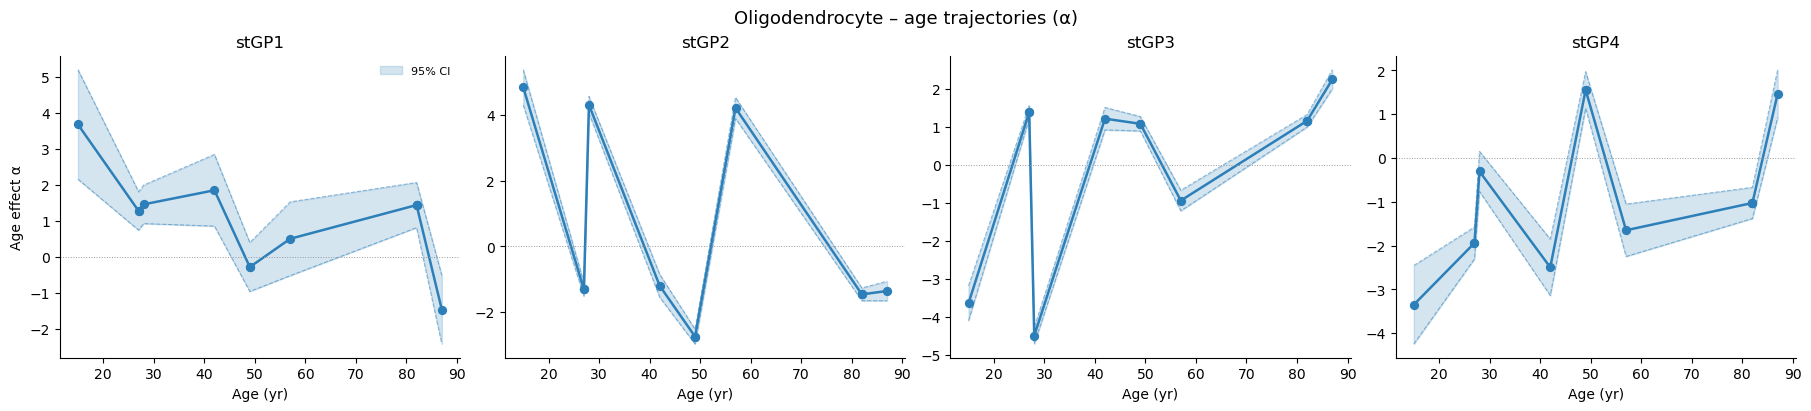

In [ ]:
stgp_info   = adata.uns["stgp"]
ages_slices = np.array(stgp_info["ages"])
alpha       = np.array(stgp_info["alpha"])        # (p, n_slices)
alpha_lower = np.array(stgp_info["alpha_lower"])
alpha_upper = np.array(stgp_info["alpha_upper"])

fig, axes = plt.subplots(1, p_sel, figsize=(4.5 * p_sel, 4), constrained_layout=True)
for j, ax in enumerate(np.atleast_1d(axes)):
    order = np.argsort(ages_slices)
    a, lo, hi = alpha[j][order], alpha_lower[j][order], alpha_upper[j][order]
    t = ages_slices[order]
    ax.fill_between(t, lo, hi, alpha=0.2, color="#2C7FB8", label="95% CI")
    ax.plot(t, lo, lw=0.8, ls="--", color="#2C7FB8", alpha=0.5)
    ax.plot(t, hi, lw=0.8, ls="--", color="#2C7FB8", alpha=0.5)
    ax.plot(t, a,  lw=1.8, color="#2C7FB8")
    ax.scatter(t, a, s=32, color="#2C7FB8", zorder=3)
    ax.axhline(0, color="0.6", lw=0.7, ls=":")
    ax.set_title(f"stGP{j+1}", fontsize=12)
    ax.set_xlabel("Age (yr)"); ax.set_ylabel("Age effect α" if j == 0 else "")
    ax.spines[["top", "right"]].set_visible(False)
    if j == 0:
        ax.legend(fontsize=8, frameon=False)

fig.suptitle("Oligodendrocyte – temporal trajectories (α)", fontsize=13)
plt.savefig(FIGURES_DIR / "alpha_trajectories.png", dpi=200, bbox_inches="tight")
plt.show()

Visualising slice: 5887_rep1  (age 49 yr, n=4293 cells)


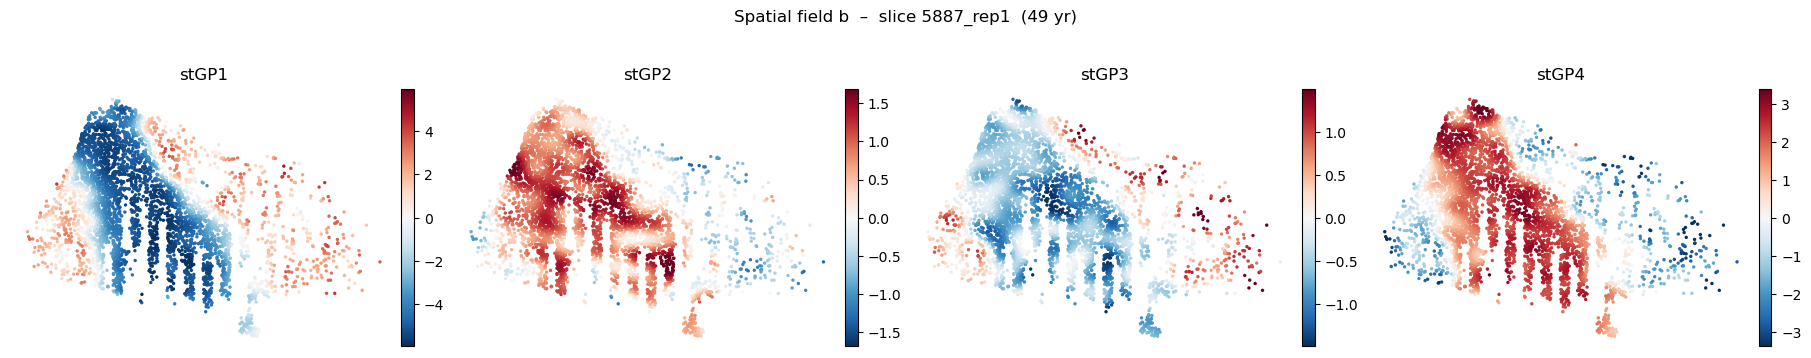

In [ ]:
# Pick a mid-age slice
slice_ages = [(adata.obs.loc[adata.obs["id_region"] == sid, "age"].iloc[0], sid)
              for sid in adata.obs["id_region"].unique()]
slice_ages.sort()
_, example_slice = slice_ages[len(slice_ages) // 2]  # middle-aged slice

sub = adata[adata.obs["id_region"].astype(str) == example_slice].copy()
age_val = sub.obs["age"].iloc[0]
print(f"Visualising slice: {example_slice}  (age {age_val:.0f} yr, n={sub.n_obs} cells)")

fig, axes = plt.subplots(1, p_sel, figsize=(4.5 * p_sel, 4), constrained_layout=True)
b = sub.obsm["X_stgp_spatial"]
xy = np.asarray(sub.obsm["spatial"])
for j, ax in enumerate(np.atleast_1d(axes)):
    v99 = np.nanpercentile(np.abs(b[:, j]), 99)
    sc_ref = ax.scatter(xy[:, 0], xy[:, 1], c=b[:, j],
                        cmap="RdBu_r", vmin=-v99, vmax=v99,
                        s=6, linewidths=0, rasterized=True)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"stGP{j+1}")
    plt.colorbar(sc_ref, ax=ax, shrink=0.7, pad=0.01)

fig.suptitle(f"Spatial field b  –  slice {example_slice}  ({age_val:.0f} yr)", fontsize=12)
plt.savefig(FIGURES_DIR / f"spatial_b_{example_slice}.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. NicheScope Comparison

In [ ]:
import json
import matplotlib as mpl
import seaborn as sns

from adjustText import adjust_text
from plots import METHOD_COLORS, save_pair

NICHE_DIR = Path("NicheScope/results/oli")
NICHE_FIGURE_DIR = FIGURES_DIR / "nichescope"
NICHE_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

shared_genes_path = NICHE_DIR / "genes_shared.csv"
young_genes_path = NICHE_DIR / "genes_young.csv"
aged_genes_path = NICHE_DIR / "genes_old.csv"
gene_lists_path = NICHE_DIR / "aging_gene_lists.json"
volcano_path = NICHE_DIR / "microglia_DE_aged_vs_young.csv"
meta_share_path = NICHE_DIR / "meta_share_microglia.pkl"
active_genes_path = OUT_DIR / "W_active_genes.csv"

STGP_COLOR = METHOD_COLORS.get("stGP", "#E64B35")
NICHE_COLOR = "#3C5488"


def mcn_gene_map(gene_df, prefix="", n_top=30, u_min=0.05):
    mapping = {}
    for comp, sub in gene_df.groupby("comp"):
        comp_num = int(str(comp).replace("comp", ""))
        label = f"{prefix}-MCN{comp_num}" if prefix else f"MCN{comp_num}"
        sub = sub.sort_values("rank").head(n_top)
        for _, row in sub.iterrows():
            if float(row["u"]) >= u_min:
                mapping.setdefault(str(row["gene"]), []).append(label)
    return mapping

shared = pd.read_csv(shared_genes_path)
gene_col = "gene" if "gene" in shared.columns else shared.columns[0]
shared_genes = shared[gene_col].astype(str).tolist()
w_active = pd.read_csv(active_genes_path)
stgp4_shared = (
    w_active[(w_active["program"] == "stGP4") & (w_active["gene"].isin(shared_genes))]
    .sort_values("weight", ascending=False)
    .head(25)
)
display(stgp4_shared)


,program,gene,weight,rank
45,stGP4,SORCS2,0.158297,1
46,stGP4,RGS11,0.149578,2
47,stGP4,MOG,0.098984,3
49,stGP4,MAT2A,0.070991,5
50,stGP4,PDIA2,0.064572,6
51,stGP4,OLIG1,0.061446,7
53,stGP4,SOX2,0.045871,9
54,stGP4,OLIG2,0.043123,10
56,stGP4,NKX2-2,0.040417,12
58,stGP4,SOX13,0.036853,14


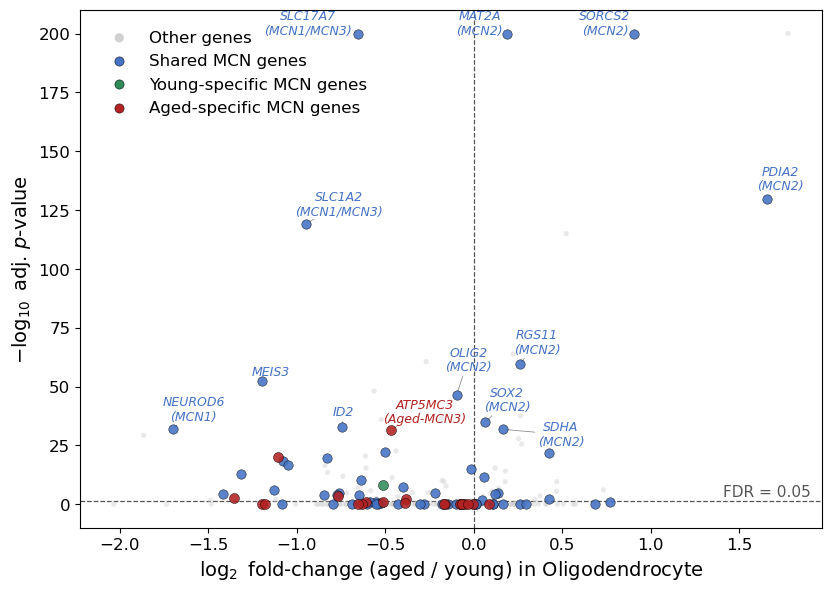

(PosixPath('Figure/oli/nichescope/ext_volcano_large.png'),
 PosixPath('Figure/oli/nichescope/ext_volcano_large.pdf'))

In [18]:
de_df = pd.read_csv(volcano_path)
with open(gene_lists_path) as f:
    lists = json.load(f)
shared = pd.read_csv(shared_genes_path)
young = pd.read_csv(young_genes_path)
aged = pd.read_csv(aged_genes_path)

young_only = set(lists.get("young_only", []))
aged_only = set(lists.get("aged_only", []))
common = set(lists.get("common_young_aged", [])) | set(lists.get("shared_only", []))
mcn_common = mcn_gene_map(shared, "")
mcn_young = mcn_gene_map(young, "Young")
mcn_aged = mcn_gene_map(aged, "Aged")

x = de_df["log2fc_aged_vs_young"].to_numpy(float)
y = -np.log10(np.clip(de_df["adj_p"].to_numpy(float), 1e-200, 1.0))
genes = de_df["gene"].astype(str)
masks = {
    "other": ~(genes.isin(young_only | aged_only | common)),
    "common": genes.isin(common),
    "young": genes.isin(young_only),
    "aged": genes.isin(aged_only),
}
colors = {"other": "#D0D0D0", "common": "#4472C4", "young": "#2E8B57", "aged": "#B22222"}
labels = {
    "other": "Other genes",
    "common": "Shared MCN genes",
    "young": "Young-specific MCN genes",
    "aged": "Aged-specific MCN genes",
}
sizes = {"other": 14, "common": 46, "young": 52, "aged": 52}

fig, ax = plt.subplots(figsize=(8.2, 5.8), constrained_layout=True)
for key in ["other", "common", "young", "aged"]:
    ax.scatter(
        x[masks[key]], y[masks[key]],
        s=sizes[key], c=colors[key], alpha=0.46 if key == "other" else 0.88,
        edgecolors="none" if key == "other" else "black",
        linewidths=0 if key == "other" else 0.35,
        label=labels[key], rasterized=(key == "other"), zorder=2 if key == "other" else 3,
    )

fdr_y = -np.log10(0.05)
ax.axhline(fdr_y, ls="--", c="#555555", lw=0.9, zorder=1)
ax.axvline(0, ls="--", c="#555555", lw=0.9, zorder=1)
ax.text(0.985, fdr_y + 0.9, "FDR = 0.05", fontsize=11, color="#555555", ha="right", va="bottom", transform=ax.get_yaxis_transform())

de_idx = de_df.set_index("gene")
texts = []
for gene_set, mapping, color in [(aged_only, mcn_aged, colors["aged"]), (young_only, mcn_young, colors["young"]), (common, mcn_common, colors["common"])]:
    for gene in gene_set:
        if gene not in de_idx.index:
            continue
        row = de_idx.loc[gene]
        if float(row["adj_p"]) > 1e-25:
            continue
        gx = float(row["log2fc_aged_vs_young"])
        gy = float(-np.log10(max(float(row["adj_p"]), 1e-200)))
        mcn = "/".join(mapping.get(gene, []))
        label = f"{gene}\n({mcn})" if mcn else gene
        texts.append(ax.text(gx, gy, label, fontsize=9, color=color, fontstyle="italic", linespacing=1.15, ha="center", va="bottom"))
if texts:
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="#888888", lw=0.55), expand=(1.2, 1.45), force_text=(0.35, 0.55), time_lim=7)

ax.set_xlabel(r"$\log_2$ fold-change (aged / young) in Oligodendrocyte", fontsize=14)
ax.set_ylabel(r"$-\log_{10}$ adj. $p$-value", fontsize=14)
ax.tick_params(labelsize=12)
leg = ax.legend(frameon=False, fontsize=12, loc="upper left", bbox_to_anchor=(0.01, 0.99))
for handle in getattr(leg, "legend_handles", getattr(leg, "legendHandles", [])):
    try:
        handle.set_sizes([44])
        handle.set_alpha(1)
    except Exception:
        pass
save_pair(fig, "ext_volcano_large", out_dir=NICHE_FIGURE_DIR, bbox_inches="tight", pad_inches=0.04)


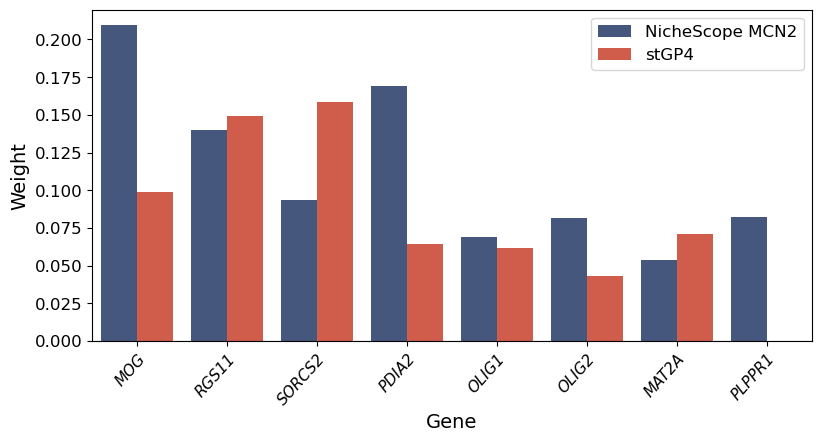

(PosixPath('Figure/oli/nichescope/mcn_union_oli_stGP4_loadings.png'),
 PosixPath('Figure/oli/nichescope/mcn_union_oli_stGP4_loadings.pdf'))

In [19]:
shared = pd.read_csv(shared_genes_path)
active = pd.read_csv(active_genes_path)
focus_comp = "comp2"
focus_program = "stGP4"
mcn = shared[shared["comp"] == focus_comp].sort_values("rank").head(10)
prog = active[active["program"] == focus_program].nsmallest(10, "rank").sort_values("weight", ascending=False)
genes = sorted(set(mcn["gene"]) | set(prog["gene"]))
mcn_s = mcn.set_index("gene")["u"]
stgp_s = prog.set_index("gene")["weight"]
tbl = pd.DataFrame({"gene": genes, "NicheScope MCN2": [mcn_s.get(g, np.nan) for g in genes], "stGP4": [stgp_s.get(g, np.nan) for g in genes]})
denom = tbl["NicheScope MCN2"].fillna(0).abs().sum()
if denom > 0:
    tbl["NicheScope MCN2"] = tbl["NicheScope MCN2"] / denom
order_score = tbl[["NicheScope MCN2", "stGP4"]].fillna(0).abs().sum(axis=1)
gene_order = tbl.loc[order_score.sort_values(ascending=False).index, "gene"].tolist()[:8]
tbl = tbl[tbl["gene"].isin(gene_order)].copy()
plot_df = tbl.melt(id_vars="gene", var_name="source", value_name="loading")
plot_df["gene"] = pd.Categorical(plot_df["gene"], categories=gene_order, ordered=True)

fig_w = max(8.0, 0.62 * len(gene_order) + 2.4)
fig, ax = plt.subplots(figsize=(fig_w, 5.1), constrained_layout=False)
sns.barplot(
    data=plot_df, x="gene", y="loading", hue="source",
    hue_order=["NicheScope MCN2", "stGP4"],
    palette={"NicheScope MCN2": NICHE_COLOR, "stGP4": STGP_COLOR}, ax=ax,
)
ax.axhline(0, color="0.82", lw=1.0, zorder=0)
ax.set_xlabel("Gene", fontsize=14)
ax.set_ylabel("Weight", fontsize=14)
ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", labelsize=11)
plt.setp(ax.get_xticklabels(), rotation=48, ha="right", rotation_mode="anchor", fontstyle="italic")
ax.legend(frameon=True, fontsize=12, loc="upper right")
fig.subplots_adjust(left=0.08, right=0.98, top=0.95, bottom=0.30)
save_pair(fig, "mcn_union_oli_stGP4_loadings", out_dir=NICHE_FIGURE_DIR, bbox_inches="tight", pad_inches=0.04)


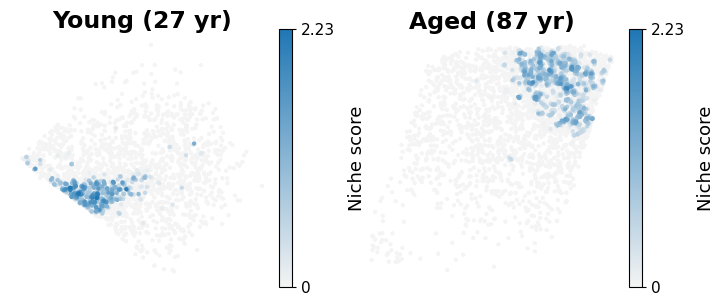

(PosixPath('Figure/oli/nichescope/score_shared_2.png'),
 PosixPath('Figure/oli/nichescope/score_shared_2.pdf'))

In [20]:
with open(meta_share_path, "rb") as f:
    meta_share = pickle.load(f)
score_df1 = meta_share["score_df1"]
score_df2 = meta_share["score_df2"]
comp = "S_comp2"
if comp not in score_df1.columns or comp not in score_df2.columns:
    raise KeyError(f"{comp} missing from NicheScope score tables")

global_vmax = max(float(score_df1[comp].max()), float(score_df2[comp].max()), 1e-6)
cmap = mpl.colors.LinearSegmentedColormap.from_list("score_shared_2_cmap", ["#F4F4F4", "#1f77b4"], N=256)
fig, axes = plt.subplots(1, 2, figsize=(8.15, 3.35), gridspec_kw={"wspace": 0.24})
for ax, sdf, ttl in zip(axes, [score_df1, score_df2], ["Young (27 yr)", "Aged (87 yr)"]):
    xy = sdf[["x", "y"]].to_numpy(float)
    score = sdf[comp].to_numpy(float)
    ax.scatter(xy[:, 0], xy[:, 1], s=2.0, c="#EDEDED", linewidths=0, rasterized=True)
    order = np.argsort(score)
    sc_ref = ax.scatter(xy[order, 0], xy[order, 1], c=score[order], s=9.5, cmap=cmap, vmin=0, vmax=global_vmax, linewidths=0, rasterized=True)
    ax.set_title(ttl, fontsize=17, fontweight="bold", pad=4)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.axis("off")
    cbar = fig.colorbar(sc_ref, ax=ax, fraction=0.046, pad=0.018)
    cbar.set_label("Niche score", fontsize=13, labelpad=9)
    cbar.ax.tick_params(labelsize=11, length=3)
    cbar.set_ticks([0, global_vmax])
    cbar.set_ticklabels(["0", f"{global_vmax:.2f}"])
save_pair(fig, "score_shared_2", out_dir=NICHE_FIGURE_DIR, bbox_inches="tight", pad_inches=0.04)
